In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/Yashappin/Machine-Learning/master/TvMarketing.csv"
data = pd.read_csv(url)

print(data.head())
print(data.info())
print(data.describe())


      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None
               TV       Sales
count  200.000000  200.000000
mean   147.042500   14.022500
std     85.854236    5.217457
min      0.700000    1.600000
25%     74.375000   10.375000
50%    149.750000   12.900000
75%    218.825000   17.400000
max    296.400000   27.000000


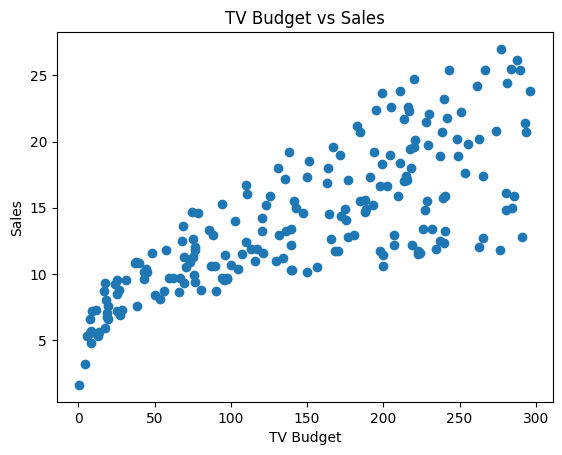

In [7]:
plt.scatter(data['TV'], data['Sales'])
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("TV Budget vs Sales")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = data[['TV']]
y = data['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Training Shape:", X_train.shape, y_train.shape)
print("Testing Shape:", X_test.shape, y_test.shape)

ModuleNotFoundError: No module named 'sklearn'

In [9]:
!python -m pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.5 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 1.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.1 MB 1.7 MB/s eta 0:00:05
   --------- ------------------------------ 1.8/8.1 MB 2.1 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.1 MB 2.0 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 2.0 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.1 MB 1.9 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.1 MB 1.8 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.1 MB 1.7 MB/s eta 0:00:03
   ------------------ ------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Bhavya\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [10]:
from sklearn.model_selection import train_test_split

X = data[['TV']]
y = data['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Training Shape:", X_train.shape, y_train.shape)
print("Testing Shape:", X_test.shape, y_test.shape)

Training Shape: (160, 1) (160,)
Testing Shape: (40, 1) (40,)


In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept (b0):", model.intercept_)
print("Coefficient (b1):", model.coef_[0])

Intercept (b0): 7.014957337855651
Coefficient (b1): 0.046392606866643635


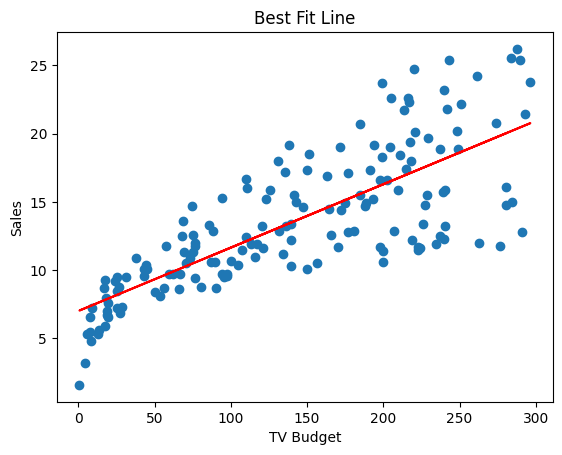

In [12]:
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train), color='red')
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("Best Fit Line")
plt.show()

In [13]:
y_pred = model.predict(X_test)

result = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(result.head())

     Actual  Predicted
112    14.1  15.166138
54     20.2  19.202295
191     9.9  10.517599
158     7.3   7.557751
175    27.0  19.861070


In [14]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 3.4867258116536934
R2 Score: 0.5731360203630529


In [27]:
import pandas as pd

df = pd.read_csv("vehicle_co2_dataset.csv")
print(df.head())

   vehicle_id      make fuel_type  model_year    engine_cc  vehicle_weight  \
0           1      Ford    Petrol        2015  1723.557940     1584.733203   
1           2  Mercedes    Petrol        2010  1425.111578     1622.249986   
2           3      Audi    Hybrid        2011  1244.080888     1473.990569   
3           4       BMW    Petrol        2009  2177.834260     1831.274096   
4           5    Toyota    Petrol        2007  1848.899157     1732.637242   

   cylinders  annual_mileage_km  vehicle_age    co2_g_km  ...  co2_proxy_51  \
0          4       10529.056031           10  156.791111  ...    149.661615   
1          4       15779.243800           15  143.193198  ...    136.682017   
2          4       14129.167461           14  123.553651  ...    117.935506   
3          4        9290.136453           16  183.750695  ...    175.395312   
4          4       25519.247019           18  188.039024  ...    179.488644   

   co2_proxy_52  co2_proxy_53  co2_proxy_54  co2_proxy_5

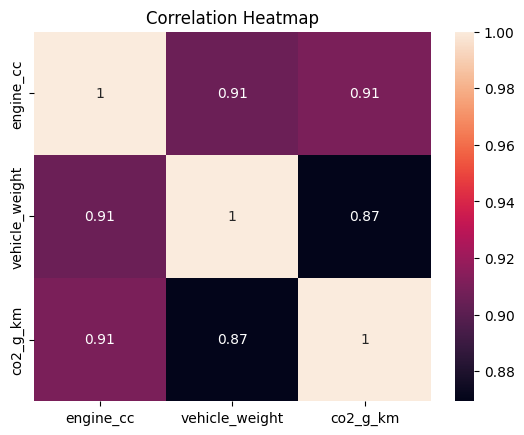

In [31]:
features = data[['engine_cc','vehicle_weight','co2_g_km']]

corr = features.corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

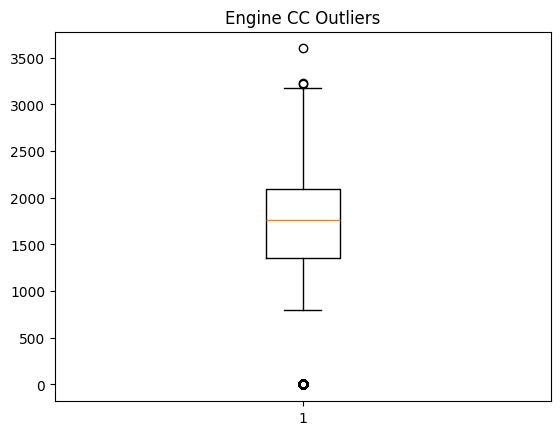

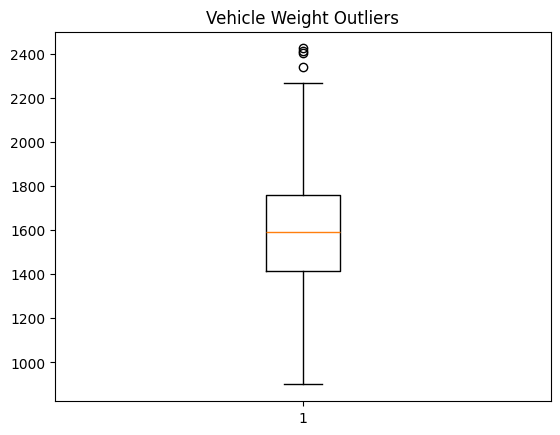

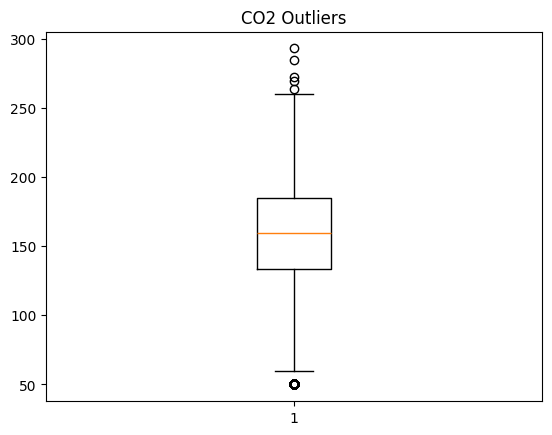

In [32]:
plt.boxplot(data['engine_cc'])
plt.title("Engine CC Outliers")
plt.show()

plt.boxplot(data['vehicle_weight'])
plt.title("Vehicle Weight Outliers")
plt.show()

plt.boxplot(data['co2_g_km'])
plt.title("CO2 Outliers")
plt.show()

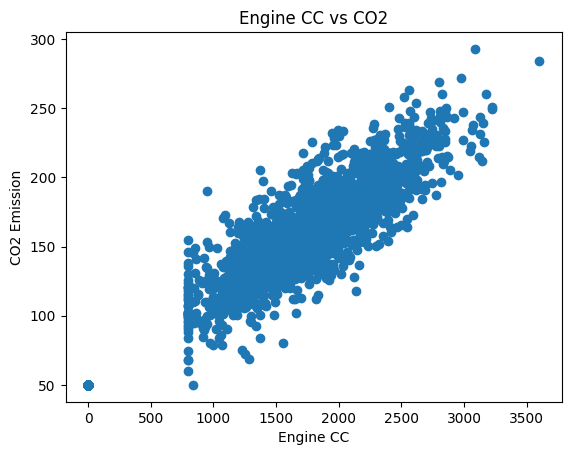

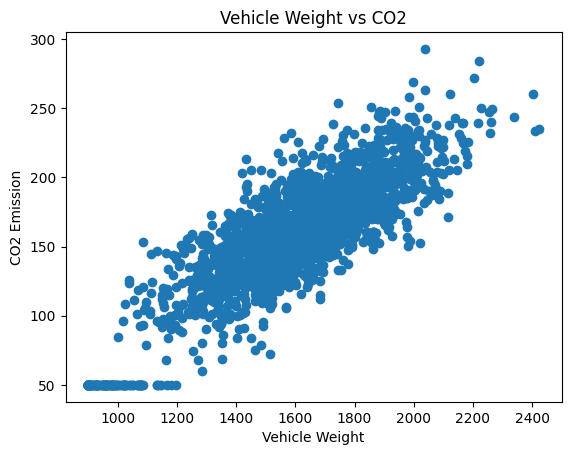

In [33]:
plt.scatter(data['engine_cc'], data['co2_g_km'])
plt.xlabel("Engine CC")
plt.ylabel("CO2 Emission")
plt.title("Engine CC vs CO2")
plt.show()

plt.scatter(data['vehicle_weight'], data['co2_g_km'])
plt.xlabel("Vehicle Weight")
plt.ylabel("CO2 Emission")
plt.title("Vehicle Weight vs CO2")
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = data[['engine_cc','vehicle_weight']]
y = data['co2_g_km']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 16.917948631731377
Coefficients: [0.0457092  0.03959215]


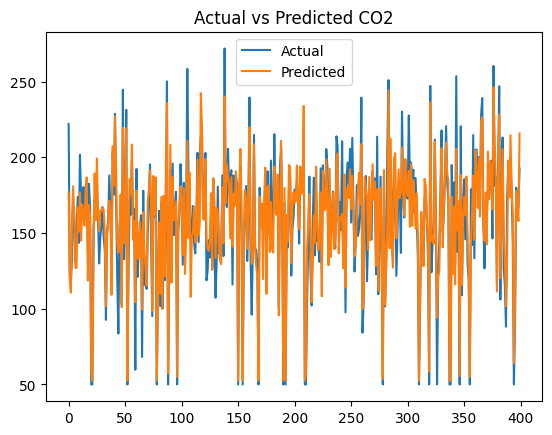

In [36]:
y_pred = model.predict(X_test)

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted CO2")
plt.show()

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 13.003161349989591
MSE: 292.2143948378195
RMSE: 17.09427959399926


In [38]:
import pandas as pd

data = pd.read_csv("advertising.csv")

print(data.head())
print(data.info())

   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

             Timestamp  Clicked on Ad  
0  2016-03-27 00:53:11              0  
1  2016-04-04 01:39:02  

In [44]:
print(data.columns)

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Male', 'Clicked on Ad'],
      dtype='str')


In [51]:
print(data.isnull().sum())

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Male                        0
Clicked on Ad               0
dtype: int64


In [52]:
print(data.describe())

       Daily Time Spent on Site          Age   Area Income  \
count               1000.000000  1000.000000   1000.000000   
mean                  65.000200    36.009000  55000.000080   
std                   15.853615     8.785562  13414.634022   
min                   32.600000    19.000000  13996.500000   
25%                   51.360000    29.000000  47031.802500   
50%                   68.215000    35.000000  57012.300000   
75%                   78.547500    42.000000  65470.635000   
max                   91.430000    61.000000  79484.800000   

       Daily Internet Usage         Male  Clicked on Ad  
count           1000.000000  1000.000000     1000.00000  
mean             180.000100     0.481000        0.50000  
std               43.902339     0.499889        0.50025  
min              104.780000     0.000000        0.00000  
25%              138.830000     0.000000        0.00000  
50%              183.130000     0.000000        0.50000  
75%              218.792500     1.0

In [53]:
X = data.drop('Clicked on Ad', axis=1)
y = data['Clicked on Ad']

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [55]:
import pandas as pd

X = pd.DataFrame(X, columns=['Daily Time Spent on Site','Age','Area Income','Daily Internet Usage','Male'])

print(X.head())

   Daily Time Spent on Site       Age  Area Income  Daily Internet Usage  \
0                  0.249267 -0.114905     0.509691              1.734030   
1                  0.961132 -0.570425     1.002530              0.313805   
2                  0.282083 -1.139826     0.356949              1.287589   
3                  0.577432 -0.798185    -0.014456              1.501580   
4                  0.212664 -0.114905     1.408868              1.038731   

       Male  
0 -0.962695  
1  1.038750  
2 -0.962695  
3  1.038750  
4 -0.962695  


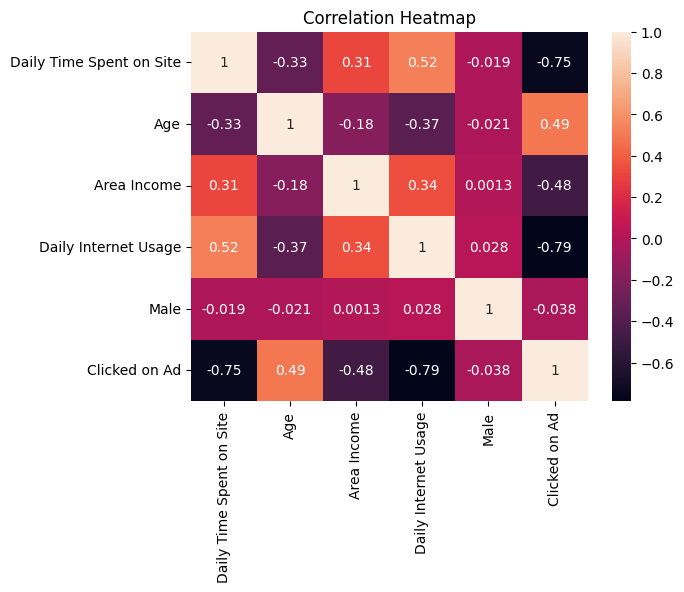

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data.corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [1.38147293]
Coefficients: [[-2.57921078  1.2069607  -1.47607063 -2.23063939 -0.07231852]]


In [58]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.985 0.96  0.99  0.96  0.96 ]
Average Accuracy: 0.9709999999999999


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       101
           1       1.00      0.96      0.98        99

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



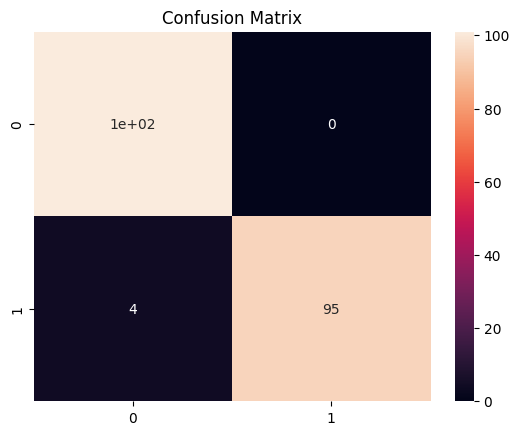

In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

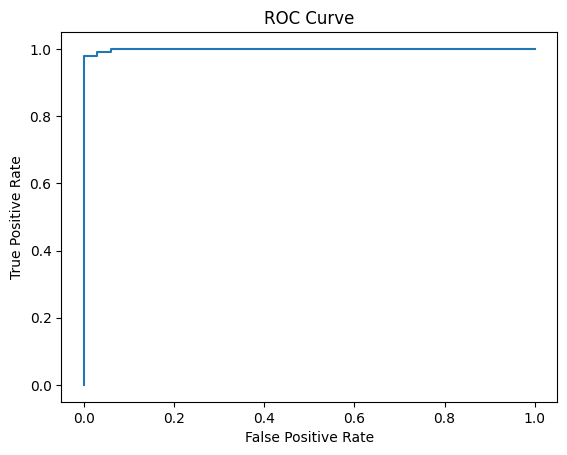

In [61]:
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

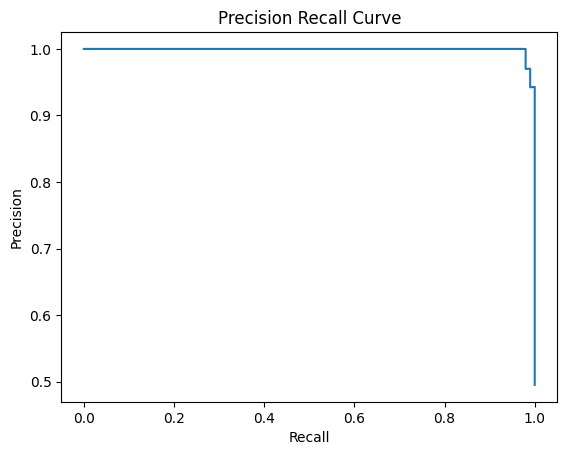

In [62]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

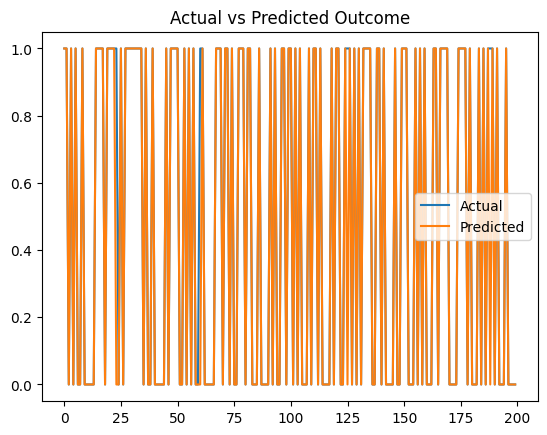

In [63]:
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Outcome")
plt.show()